# 07 - Görsel Benzerlik Analizi (Similarity Analysis)

## Amaç

Bu notebook içerisinde DINOv2 modeli kullanılarak oluşturulan embeddingler üzerinden görseller arasındaki benzerlik analizleri gerçekleştirilecektir.

Embeddingler aynı görsel özelliklerini taşıyan görüntülerin birbirine yakın olmasını sağlayan sayısal temsillerdir.

Bu notebook sonunda;

- Görseller arasındaki Cosine Similarity hesaplanacaktır.
- Benzerlik matrisi oluşturulacaktır.
- En benzer görüntüler belirlenecektir.
- Kültürel temaların birbirleriyle olan görsel ilişkileri incelenecektir.

Bu analiz ilerleyen aşamalarda gerçek ve yapay zekâ tarafından üretilen görüntülerin karşılaştırılmasında referans olarak kullanılacaktır.

# Gerekli Kütüphaneler

Bu bölümde benzerlik analizi için gerekli Python kütüphaneleri yüklenmektedir.

NumPy:

Sayısal işlemler.

Pandas:

Metadata işlemleri.

Matplotlib:

Grafikler.

Scikit-Learn:

Cosine Similarity hesabı.

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.metrics.pairwise import cosine_similarity

print("Kütüphaneler yüklendi.")

Kütüphaneler yüklendi.


# Embedding Dosyasının Okunması

Bu bölümde önceki notebookta oluşturulan embedding dosyası okunmaktadır.

Embeddingler DINOv2 modelinin ürettiği 768 boyutlu özellik vektörleridir.

Bu vektörler kullanılarak benzerlik hesaplanacaktır.

In [2]:
embeddings = np.load(
    "../embeddings/chrd_real_embeddings.npy"
)

print("Embedding Boyutu :", embeddings.shape)

Embedding Boyutu : (82, 768)


# Metadata Dosyasının Okunması

Embeddinglerin hangi görsele ait olduğunu belirleyebilmek için metadata dosyası okunmaktadır.

Embedding sayısı kadar satır kullanılacaktır.

In [3]:
df = pd.read_csv(
    "../data/CHRD_Real/metadata_selected.csv",
    sep=";"
)

df = df.iloc[:len(embeddings)].reset_index(drop=True)

print(df.shape)

(82, 11)


# Cosine Similarity Hesaplanması

Bu bölümde tüm embeddingler arasındaki Cosine Similarity değerleri hesaplanmaktadır.

Cosine Similarity değeri;

- 1 → tamamen aynı
- 0 → ilişkisiz
- -1 → tamamen zıt

anlamına gelmektedir.

DINOv2 embeddinglerinde benzer görüntüler genellikle 0.70 ile 1.00 arasında değer almaktadır.

In [4]:
similarity_matrix = cosine_similarity(embeddings)

print(similarity_matrix.shape)

(82, 82)


# İlk Benzerlik Değerlerinin İncelenmesi

Oluşturulan benzerlik matrisinin ilk birkaç satırı görüntülenmektedir.

Bu tablo her görselin diğer görsellerle olan benzerlik skorlarını göstermektedir.

In [5]:
pd.DataFrame(similarity_matrix).head()

,0,1,2,3,4,5,6,7,8,9,...,72,73,74,75,76,77,78,79,80,81
0,1.000000,0.379513,0.494476,0.333673,0.144420,0.476283,0.187067,0.255183,0.480132,0.464587,...,0.550499,0.393984,0.336043,0.290175,0.200857,0.308370,0.362392,0.259861,0.389100,0.456621
1,0.379513,1.000000,0.486685,0.191146,0.226874,0.419853,0.200727,0.359843,0.228301,0.585605,...,0.531642,0.631025,0.275205,0.538454,0.267991,0.398465,0.510364,0.266198,0.474898,0.416523
2,0.494476,0.486685,1.000000,0.183003,0.134526,0.417470,0.144336,0.525583,0.418191,0.686841,...,0.496869,0.455760,0.339101,0.497896,0.172582,0.420994,0.303420,0.214827,0.472512,0.601045
3,0.333673,0.191146,0.183003,1.000000,0.234033,0.248792,0.424872,0.086946,0.185365,0.218091,...,0.263125,0.219438,0.278689,0.218764,0.305677,0.158750,0.146962,0.329570,0.120008,0.097186
4,0.144420,0.226874,0.134526,0.234033,1.000000,0.295580,0.428722,0.076601,0.076007,0.170916,...,0.319954,0.354537,0.348956,0.264317,0.500804,0.317691,0.249440,0.436716,0.194401,0.065218


# Benzerlik Matrisinin Görselleştirilmesi

Bu bölümde DINOv2 embeddinglerinden elde edilen Cosine Similarity matrisi görselleştirilmektedir.

Grafikte;

- Her satır ve sütun bir görüntüyü temsil etmektedir.
- Renk yoğunluğu iki görüntü arasındaki benzerlik seviyesini göstermektedir.
- Köşegen üzerindeki değerler her görüntünün kendisiyle olan benzerliğini ifade ettiği için 1 değerine sahiptir.

Bu görselleştirme veri kümesindeki genel benzerlik yapısını incelemek amacıyla kullanılmaktadır.

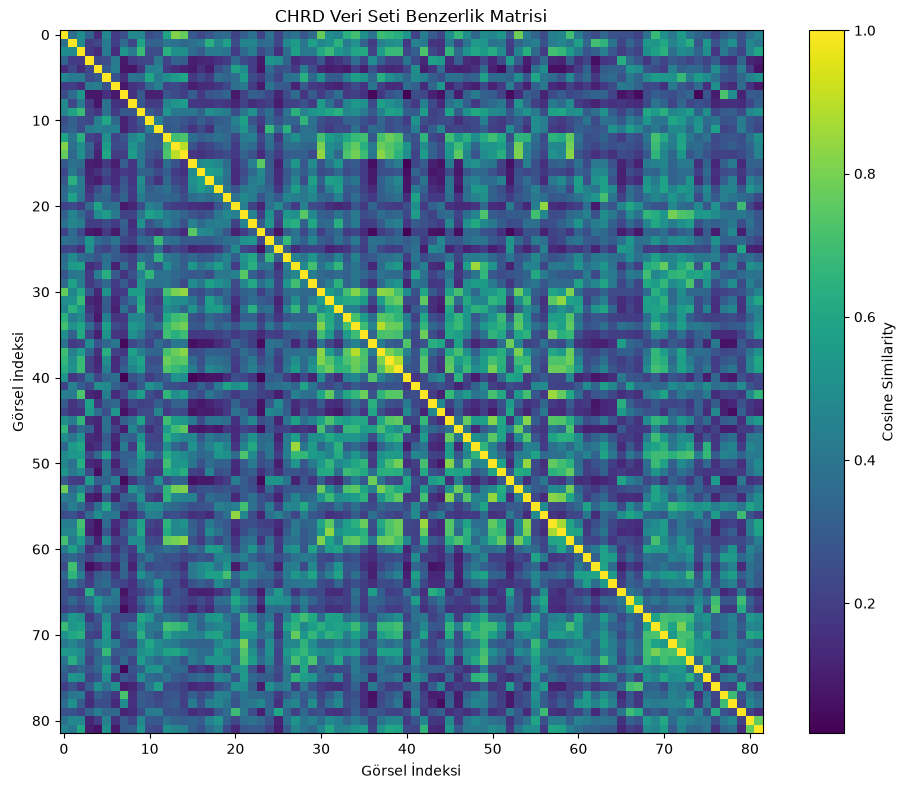

In [6]:
plt.figure(figsize=(10,8))

plt.imshow(similarity_matrix, cmap="viridis")

plt.colorbar(label="Cosine Similarity")

plt.title("CHRD Veri Seti Benzerlik Matrisi")

plt.xlabel("Görsel İndeksi")

plt.ylabel("Görsel İndeksi")

plt.tight_layout()

plt.show()

# En Benzer Görsellerin Belirlenmesi

Bu bölümde her görüntü için veri kümesindeki en benzer ikinci görüntü belirlenmektedir.

Birinci en yüksek değer her zaman görüntünün kendisi olduğu için değerlendirme dışı bırakılmaktadır.

Bu analiz sayesinde kültürel olarak birbirine en çok benzeyen görüntüler belirlenebilmektedir.

In [7]:
similarity_copy = similarity_matrix.copy()

np.fill_diagonal(similarity_copy, -1)

most_similar_index = np.argmax(similarity_copy, axis=1)

similarity_scores = similarity_copy.max(axis=1)

# En Benzer Görseller Tablosu

Bu tabloda her görüntü için;

- Görsel adı
- Teması
- En çok benzediği görüntü
- Benzerlik skoru

listelenmektedir.

Bu tablo veri kümesindeki kültürel ve görsel benzerliklerin incelenmesini sağlamaktadır.

In [8]:
results = pd.DataFrame({

    "file_name": df["file_name"],

    "theme": df["theme"],

    "most_similar_file":
        df.iloc[most_similar_index]["file_name"].values,

    "most_similar_theme":
        df.iloc[most_similar_index]["theme"].values,

    "similarity_score":
        np.round(similarity_scores,4)

})

results.head(15)

,file_name,theme,most_similar_file,most_similar_theme,similarity_score
0,CHRD_REAL_0001.jpeg,Rock-cut Heritage,CHRD_REAL_0021.jpeg,Rock-cut Heritage,0.8148
1,CHRD_REAL_0004.jpeg,Village Square,CHRD_REAL_0079.jpeg,Village Square,0.7023
2,CHRD_REAL_0005.jpeg,Fairy Chimney,CHRD_REAL_0058.jpeg,Fairy Chimney,0.7220
3,CHRD_REAL_0006.jpeg,Local Architecture,CHRD_REAL_0083.jpeg,Daily Life,0.6290
4,CHRD_REAL_0007.jpeg,Daily Life,CHRD_REAL_0031.jpeg,Natural Landscape,0.5827
5,CHRD_REAL_0008.jpeg,Local Architecture,CHRD_REAL_0090.jpeg,Daily Life,0.6716
6,CHRD_REAL_0009.jpeg,Daily Life,CHRD_REAL_0060.jpeg,Local Architecture,0.5332
7,CHRD_REAL_0011.jpeg,Natural Landscape,CHRD_REAL_0095.jpeg,Local Architecture,0.7171
8,CHRD_REAL_0014.jpeg,Daily Life,CHRD_REAL_0050.jpeg,Local Architecture,0.5733
9,CHRD_REAL_0015.jpeg,Village Square,CHRD_REAL_0005.jpeg,Fairy Chimney,0.6868


# Benzerlik Skorlarının Dağılımı

Bu bölümde veri kümesindeki tüm en yüksek benzerlik skorlarının dağılımı incelenmektedir.

Histogram grafiği;

- yüksek benzerlik gösteren görüntülerin yoğunluğunu,
- veri kümesinin genel benzerlik seviyesini,
- kültürel çeşitliliğin dağılımını

göstermektedir.

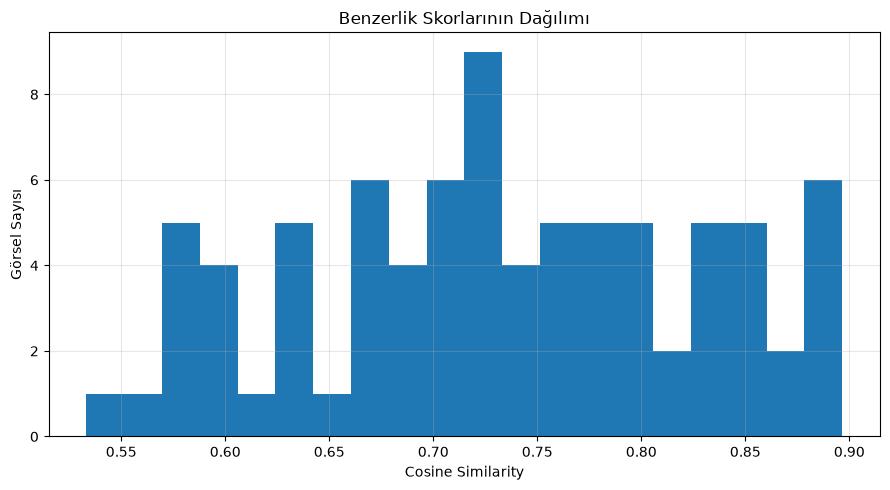

In [9]:
plt.figure(figsize=(9,5))

plt.hist(
    similarity_scores,
    bins=20
)

plt.title("Benzerlik Skorlarının Dağılımı")

plt.xlabel("Cosine Similarity")

plt.ylabel("Görsel Sayısı")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

# Tema Bazında Ortalama Benzerlik

Bu bölümde her tema için ortalama en yüksek benzerlik değeri hesaplanmaktadır.

Bu analiz hangi kültürel temaların kendi içerisinde daha tutarlı olduğunu göstermektedir.

In [10]:
theme_similarity = (

results

.groupby("theme")["similarity_score"]

.mean()

.sort_values(ascending=False)

)

theme_similarity

theme
Fairy Chimney         0.823844
Rock-cut Heritage     0.809413
Local Architecture    0.711337
Daily Life            0.703171
Natural Landscape     0.693386
Village Square        0.683345
Name: similarity_score, dtype: float32

# Tema Bazında Ortalama Benzerlik Grafiği

Bu grafik her kültürel temanın kendi içerisindeki ortalama görsel benzerliğini göstermektedir.

Yüksek ortalama benzerlik değerine sahip temalar görsel olarak daha tutarlı özellikler taşımaktadır.

Düşük değerler ise aynı tema içerisinde daha fazla çeşitlilik bulunduğunu göstermektedir.

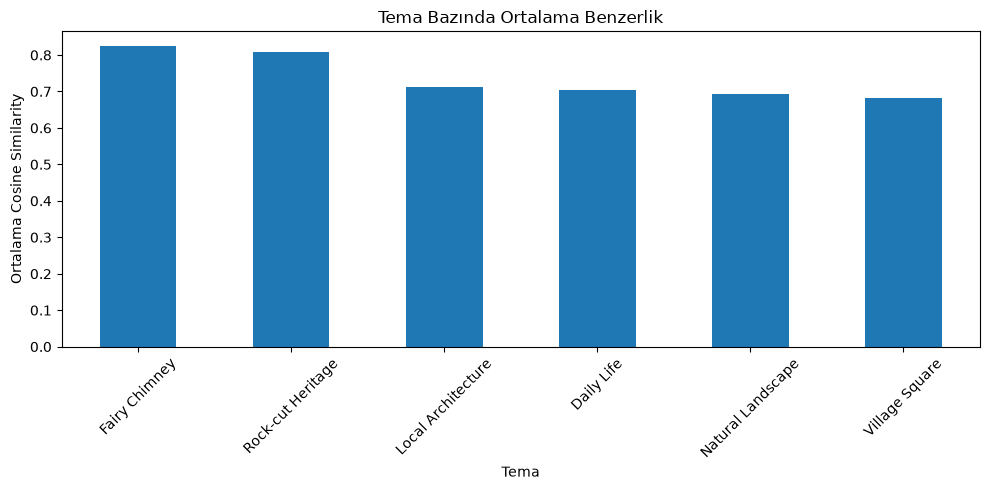

In [11]:
plt.figure(figsize=(10,5))

theme_similarity.plot(kind="bar")

plt.title("Tema Bazında Ortalama Benzerlik")

plt.xlabel("Tema")

plt.ylabel("Ortalama Cosine Similarity")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

# Sonuçların Kaydedilmesi

Bu bölümde oluşturulan benzerlik tablosu daha sonraki analizlerde kullanılmak üzere proje klasörüne kaydedilmektedir.

Bu dosya ilerleyen aşamalarda gerçek ve üretken yapay zekâ tarafından oluşturulan görüntülerin karşılaştırılmasında referans olarak kullanılacaktır.

In [12]:
import os

os.makedirs("../results", exist_ok=True)

results.to_csv(

    "../results/chrd_similarity_results.csv",

    index=False,

    encoding="utf-8-sig"

)

print("Benzerlik analizi başarıyla kaydedildi.")

Benzerlik analizi başarıyla kaydedildi.


# Genel Değerlendirme

Bu notebook içerisinde DINOv2 modeli kullanılarak oluşturulan embeddingler üzerinden görsel benzerlik analizi gerçekleştirilmiştir.

Gerçekleştirilen işlemler:

- Cosine Similarity matrisi hesaplanmıştır.
- Benzerlik matrisi görselleştirilmiştir.
- Her görüntü için en benzer kültürel görüntü belirlenmiştir.
- Tema bazında ortalama benzerlik değerleri hesaplanmıştır.
- Sonuçlar grafiklerle desteklenmiştir.
- Analiz sonuçları proje klasörüne kaydedilmiştir.

Bir sonraki aşamada bu sonuçlar kullanılarak gerçek görüntüler ile üretken yapay zekâ modelleri tarafından oluşturulan görüntüler karşılaştırılacaktır.